In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from pycaret.regression import *

from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Data Prep


## Data Prep


In [36]:
data_25_26 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/Prediction%20with%20Affine%20PNN/data/rolled_player_data.csv')
gw=21

cols = [

    'fpl_id', 'round', 'fpl_name', 'position', 'team_id', 'team', 'opponent_team', 'was_home', 'xP', 'xP_next',
    'selected_by_percent','value', 'form', 'value_form', 'chance_of_playing_next_round', 'chance_of_playing_this_round',
    'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    # 'influence', 'creativity', 'threat', 'ict_index',
    'elo', 'strength',
    'strength_overall_home', 'strength_overall_away', 'strength_attack_home', 'strength_attack_away', 'strength_defence_home', 'strength_defence_away',
    'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob',


    'creativity_1', 'creativity_3', 'creativity_5', 'influence_1', 'influence_3', 'influence_5', 'threat_1', 'threat_3', 'threat_5', 'minutes_1', 'minutes_3',
    'minutes_5', 'pts_bonus_1', 'pts_bonus_3', 'pts_bonus_5', 'expected_goals_1', 'expected_goals_3',
    'expected_goals_5', 'expected_assists_1', 'expected_assists_3', 'expected_assists_5', 'xP_1', 'xP_3', 'xP_5', 'expected_goals_conceded_1',
    'expected_goals_conceded_3', 'expected_goals_conceded_5', 'goals_conceded_1', 'goals_conceded_3', 'goals_conceded_5', 'goals_scored_1', 'goals_scored_3',
    'goals_scored_5', 'shots_1', 'shots_3', 'shots_5', 'key_passes_1', 'key_passes_3', 'key_passes_5', 'npg_1', 'npg_3', 'npg_5', 'npxG_1', 'npxG_3', 'npxG_5',
    'goals_1', 'goals_3', 'goals_5', 'xG_1', 'xG_3', 'xG_5', 'xA_1', 'xA_3', 'xA_5', 'saves_1', 'saves_3', 'saves_5', 'starts_1', 'starts_3', 'starts_5',
    'yellow_cards_1', 'yellow_cards_3', 'yellow_cards_5', 'red_cards_1', 'red_cards_3', 'red_cards_5', 'assists_1', 'assists_3', 'assists_5', 'clean_sheets_1',
    'clean_sheets_3', 'clean_sheets_5', 'value_1', 'value_3', 'value_5', 'ict_index_1', 'ict_index_3', 'ict_index_5', 'selected_1', 'selected_3', 'selected_5',
    'transfers_in_1', 'transfers_in_3', 'transfers_in_5', 'transfers_out_1', 'transfers_out_3', 'transfers_out_5', 'ownership_change_1', 'ownership_change_3',
    'ownership_change_5', 'percenatge_net_transfers_1', 'percenatge_net_transfers_3', 'percenatge_net_transfers_5', 'xGChain_1', 'xGChain_3', 'xGChain_5',
    'xGBuildup_1', 'xGBuildup_3', 'xGBuildup_5', 'expected_goal_involvements_1', 'expected_goal_involvements_3', 'expected_goal_involvements_5', 'form_1', 'form_3',
    'form_5', 'clearances_blocks_interceptions_1', 'clearances_blocks_interceptions_3', 'clearances_blocks_interceptions_5', 'tackles_1', 'tackles_3', 'tackles_5',
    'recoveries_1', 'recoveries_3', 'recoveries_5', 'defensive_contribution_1', 'defensive_contribution_3', 'defensive_contribution_5', 'selected_by_percent_1',
    'selected_by_percent_3', 'selected_by_percent_5', 'strength_1', 'strength_3', 'strength_5', 'strength_overall_home_1', 'strength_overall_home_3',
    'strength_overall_home_5', 'strength_overall_away_1', 'strength_overall_away_3', 'strength_overall_away_5', 'strength_attack_home_1', 'strength_attack_home_3',
    'strength_attack_home_5', 'strength_attack_away_1', 'strength_attack_away_3', 'strength_attack_away_5', 'strength_defence_home_1', 'strength_defence_home_3',
    'strength_defence_home_5', 'strength_defence_away_1', 'strength_defence_away_3', 'strength_defence_away_5',


    'opp_elo', 'opp_strength']

data_25_26 = data_25_26.rename({'web_name': 'fpl_name'}, axis=1)

pos_map = {
    'Goalkeeper': 'GK',
    '1': 'GK',
    'Defender': 'DEF',
    '2': 'DEF',
    'Midfielder': 'MID',
    '3': 'MID',
    'Forward': 'FWD',
    '4': 'FWD'
}
data_25_26['position'] = data_25_26['position'].map(pos_map)
data_25_26 = data_25_26[(data_25_26['minutes_1'] > 0) | (data_25_26['minutes_3'] >= 0) ]

active_data = data_25_26[cols].copy()
active_data_ = active_data.copy()


active_data_['opponent_difficulty'] = active_data_.apply(
    lambda row: (row['draw_prob'] + row['lose_prob'])
    if row['was_home']
    else (row['draw_prob'] + row['win_prob']),
    axis=1
)

active_data_['team_difficulty'] = active_data_.apply(
    lambda row: (row['draw_prob'] + row['lose_prob'])
    if not row['was_home']
    else (row['draw_prob'] + row['win_prob']),
    axis=1
)



CATEGORICAL_COLS = ['position', 'team', 'opponent_team']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(active_data_[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(active_data_[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=active_data_.index
)


cols = [*cols, *encoded_cols]
# Combine with numerical data
active_data_ = pd.concat([active_data_, encoded_df], axis=1).drop(columns=CATEGORICAL_COLS)
active_data_

,fpl_id,round,fpl_name,team_id,was_home,xP,xP_next,selected_by_percent,value,form,value_form,chance_of_playing_next_round,chance_of_playing_this_round,transfers_in,transfers_out,selected,ownership_change,percenatge_net_transfers,elo,strength,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,team_h_difficulty,team_a_difficulty,win_prob,draw_prob,lose_prob,creativity_1,creativity_3,creativity_5,influence_1,influence_3,influence_5,threat_1,threat_3,threat_5,minutes_1,minutes_3,minutes_5,pts_bonus_1,pts_bonus_3,pts_bonus_5,expected_goals_1,expected_goals_3,expected_goals_5,expected_assists_1,expected_assists_3,expected_assists_5,xP_1,xP_3,xP_5,expected_goals_conceded_1,expected_goals_conceded_3,expected_goals_conceded_5,goals_conceded_1,goals_conceded_3,goals_conceded_5,goals_scored_1,goals_scored_3,goals_scored_5,shots_1,shots_3,shots_5,key_passes_1,key_passes_3,key_passes_5,npg_1,npg_3,npg_5,npxG_1,npxG_3,npxG_5,goals_1,goals_3,goals_5,xG_1,xG_3,xG_5,xA_1,xA_3,xA_5,saves_1,saves_3,saves_5,starts_1,starts_3,starts_5,yellow_cards_1,yellow_cards_3,yellow_cards_5,red_cards_1,red_cards_3,red_cards_5,assists_1,assists_3,assists_5,clean_sheets_1,clean_sheets_3,clean_sheets_5,value_1,value_3,value_5,ict_index_1,ict_index_3,ict_index_5,selected_1,selected_3,selected_5,transfers_in_1,transfers_in_3,transfers_in_5,transfers_out_1,transfers_out_3,transfers_out_5,ownership_change_1,ownership_change_3,ownership_change_5,percenatge_net_transfers_1,percenatge_net_transfers_3,percenatge_net_transfers_5,xGChain_1,xGChain_3,xGChain_5,xGBuildup_1,xGBuildup_3,xGBuildup_5,expected_goal_involvements_1,expected_goal_involvements_3,expected_goal_involvements_5,form_1,form_3,form_5,clearances_blocks_interceptions_1,clearances_blocks_interceptions_3,clearances_blocks_interceptions_5,tackles_1,tackles_3,tackles_5,recoveries_1,recoveries_3,recoveries_5,defensive_contribution_1,defensive_contribution_3,defensive_contribution_5,selected_by_percent_1,selected_by_percent_3,selected_by_percent_5,strength_1,strength_3,strength_5,strength_overall_home_1,strength_overall_home_3,strength_overall_home_5,strength_overall_away_1,strength_overall_away_3,strength_overall_away_5,strength_attack_home_1,strength_attack_home_3,strength_attack_home_5,strength_attack_away_1,strength_attack_away_3,strength_attack_away_5,strength_defence_home_1,strength_defence_home_3,strength_defence_home_5,strength_defence_away_1,strength_defence_away_3,strength_defence_away_5,opp_elo,opp_strength,opponent_difficulty,team_difficulty,position_DEF,position_FWD,position_GK,position_MID,team_Arsenal,team_Aston Villa,team_Bournemouth,team_Brentford,team_Brighton,team_Burnley,team_Chelsea,team_Crystal Palace,team_Everton,team_Fulham,team_Leeds,team_Liverpool,team_Man City,team_Man Utd,team_Newcastle,team_Nott'm Forest,team_Spurs,team_Sunderland,team_West Ham,team_Wolves,opponent_team_1.0,opponent_team_2.0,opponent_team_3.0,opponent_team_4.0,opponent_team_5.0,opponent_team_6.0,opponent_team_7.0,opponent_team_8.0,opponent_team_9.0,opponent_team_10.0,opponent_team_11.0,opponent_team_12.0,opponent_team_13.0,opponent_team_14.0,opponent_team_15.0,opponent_team_16.0,opponent_team_17.0,opponent_team_18.0,opponent_team_19.0,opponent_team_20.0
0,1.0,1,Raya,1.0,False,4.2,4.2,36.9,55.0,3.2,0.5,100.0,100.0,3072169.0,1125554.0,1531911.0,0.0,0.463731,2037.000000,4.0,1320.0,1325.0,1350.0,1350.0,1290.0,1300.0,4.0,3.0,0.260,0.260,0.480,1.015,1.127778,0.76875,15.79,14.837037,14.2525,0.0,0.0,0.0,90.0,90.0,90.0,3.8,3.777778,3.8,0.0,0.0,0.0,0.002,0.002222,0.002,4.83,4.833333,4.75625,0.7535,0.675370,0.648625,0.7,0.685185,0.6875,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.111111,0.075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005395,0.005995,0.004046,1.6,1.425926,1.3625,1.0,1.0,1.0,0.05,0.018519,0.0125,0.0,0.0,0.0,0.0,0.0,0.0,0.45,0.444444,0.45,57.7,57.722222,57.75,1.685,1.603704,1.51,3592683.6,3.645242e+06,3672273.15,317799.6,2.312671e+05,220109.712

In [ ]:
def working_df(data, gw):
    GW_full = data['round'].values

    # Split
    GW_TRAIN_END = gw - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data[train_mask]
    test_data = data[test_mask]

    test_player_names = test_data['fpl_name'].values
    test_data = test_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])
    train_data = train_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])

    return train_data, test_data, test_player_names



## Predict


### GW 20


#### Train


,Description,Value
0,Session id,2706
1,Target,xP
2,Target type,Regression
3,Original data shape,"(5736, 216)"
4,Transformed data shape,"(5736, 138)"
5,Transformed train set shape,"(4588, 138)"
6,Transformed test set shape,"(1148, 138)"
7,Numeric features,214
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.1061,0.0513,0.2112,0.9882,0.0687,0.0750,55.7000
gbr,Gradient Boosting Regressor,0.1365,0.0595,0.2382,0.9859,0.0813,0.0978,2.5060
et,Extra Trees Regressor,0.1433,0.0766,0.2723,0.9818,0.0889,0.1011,4.0580
ridge,Ridge Regression,0.1541,0.0686,0.2572,0.9837,0.0904,0.1168,0.3590
rf,Random Forest Regressor,0.1671,0.0884,0.2935,0.9789,0.0973,0.1208,7.5410
dt,Decision Tree Regressor,0.1996,0.1596,0.3972,0.9613,0.1316,0.1454,0.6100
ada,AdaBoost Regressor,0.3684,0.2319,0.4810,0.9436,0.1530,0.2529,1.2550
en,Elastic Net,0.4879,0.3919,0.6253,0.9047,0.2100,0.4238,0.4550
lasso,Lasso Regression,0.5369,0.4713,0.6858,0.8853,0.2283,0.4715,0.5120
llar,Lasso Least Angle Regression,0.5370,0.4715,0.6859,0.8853,0.2284,0.4716,0.3970


LGBMRegressor(n_jobs=-1, random_state=2706)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

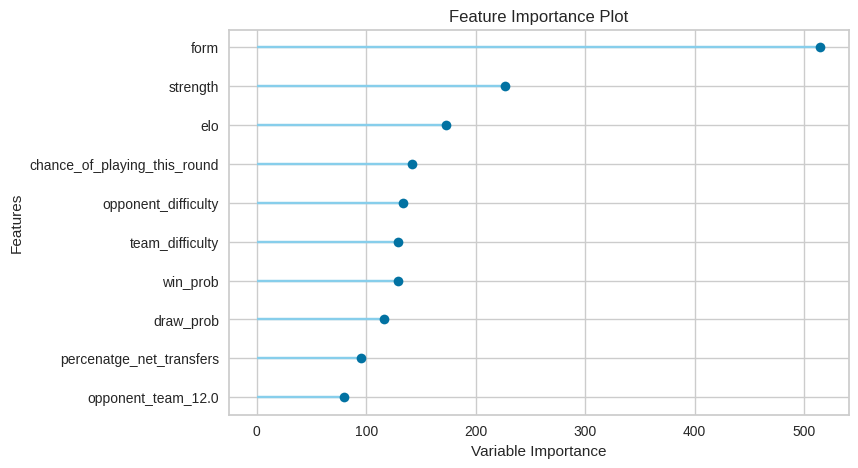

In [44]:
train_data, test_data, player_names = working_df(active_data_, 20)
base_model = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features

                )

best_model_20 = base_model.compare_models(sort='MAE', n_select=1)
print(best_model_20)

evaluate_model(best_model_20)

plot_model(best_model_20, plot='feature')        # Feature importance

##### Tune Model


In [ ]:
# tuned = tune_model(base_def_xg_best,
#                 #    verbose = False,   # This keeps the PyCaret grid visible
#                    return_train_score = True,
#                    optimize='MAE')

#### Predict


In [54]:
test_df = test_data.copy()
test_target = test_data['xP']
test_data_features = test_data.drop(columns=['xP'])

prediction_20 = predict_model(best_model_20, test_data_features)
prediction_20

,was_home,xP_next,selected_by_percent,value,form,value_form,chance_of_playing_next_round,chance_of_playing_this_round,transfers_in,transfers_out,...,opponent_team_12.0,opponent_team_13.0,opponent_team_14.0,opponent_team_15.0,opponent_team_16.0,opponent_team_17.0,opponent_team_18.0,opponent_team_19.0,opponent_team_20.0,prediction_label
20,True,3.3,33.700001,59.0,2.3,0.4,100.0,100.0,3301614.0,1723428.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.753733
21,True,1.0,0.400000,41.0,0.0,0.0,100.0,100.0,12165.0,71550.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.379862
22,True,1.0,0.300000,39.0,0.0,0.0,100.0,100.0,31141.0,26581.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.322901
37,True,5.2,29.100000,67.0,4.2,0.6,100.0,100.0,6066145.0,4918994.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.477816
54,True,3.2,11.600000,59.0,2.2,0.4,100.0,100.0,1335879.0,1875063.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.853998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6629,False,-0.5,0.000000,40.0,0.0,0.0,100.0,100.0,32.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.258259
6630,False,0.0,0.000000,40.0,0.0,0.0,100.0,100.0,47.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.275210
6631,False,0.0,0.000000,45.0,0.0,0.0,100.0,100.0,45.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.247109
6632,True,1.9,0.000000,55.0,2.0,0.4,100.0,100.0,566.0,34.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.048733


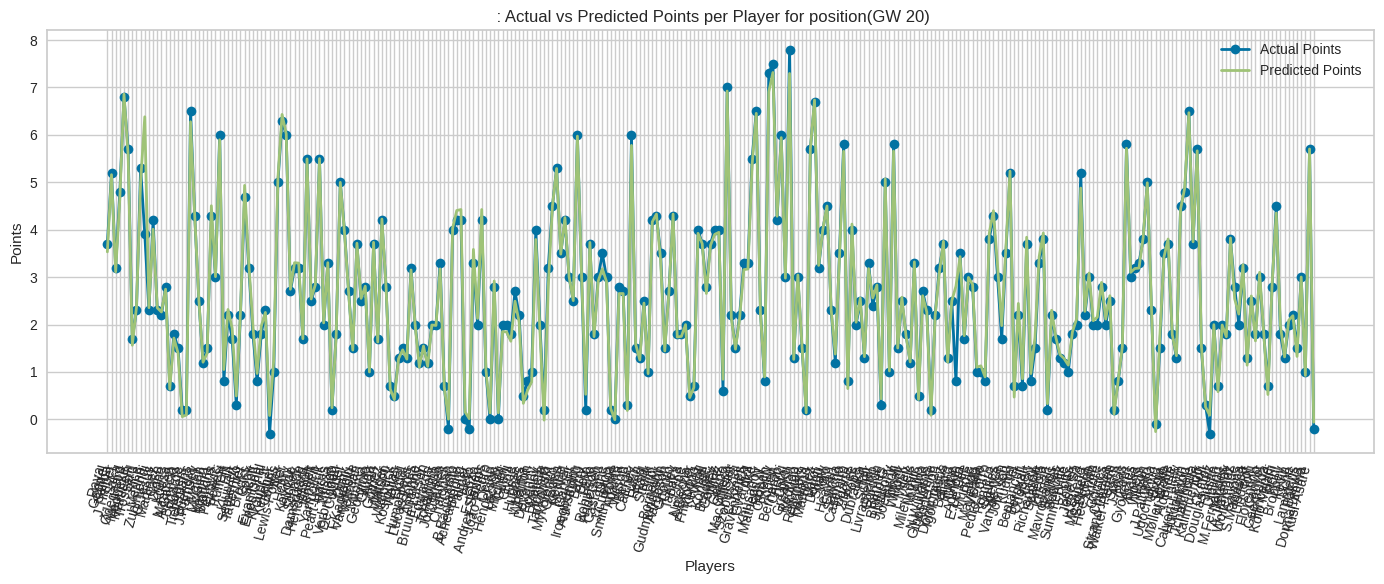

In [52]:
xp_actual = test_target
xp_pred = prediction_20['prediction_label'].values


# Convert names to positions on x-axis
x = np.arange(len(player_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, xp_actual, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, xp_pred, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, player_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title(f" : Actual vs Predicted Points per Player for position(GW 20)")
plt.legend()
plt.tight_layout()

plt.show()



# Current GW


In [63]:
train_data, test_data, player_names = working_df(active_data_, 21)
test_df = test_data.copy()
test_target = test_data['xP']
test_data_features = test_data.drop(columns=['xP'])

prediction_21 = predict_model(best_model_20, test_data_features)
prediction_21['names'] = player_names
prediction_21[['prediction_label', 'names']].sort_values(by='prediction_label', ascending=False) #.head(10).round(2).to_string(index=False)

,prediction_label,names
218,6.381304,Rice
3615,6.288471,Matheus N.
3882,6.273816,Haaland
443,6.133201,Rogers
3421,5.963661,Wirtz
...,...,...
1220,-0.554789,Steele
1349,-0.566482,Tasker
1553,-0.568802,Tzimas
1523,-0.572254,Knight


#### Optimize


In [ ]:
squad_16, total_points_16 = get_optimized_team(Y_pred_16, 16)
squad_16

Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-224.8333
IRL epoch 100/200 loss=-2410.7791
IRL epoch 150/200 loss=-10233.9131
IRL epoch 200/200 loss=-28000.5898
HGAT Policy Embeddings Shape: torch.Size([297, 32])
Restricted license - for non-production use only - expires 2027-11-29

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
            name           team position  price    xP_pred  is_captain  \
5           Saka        Arsenal      MID   10.2   8.062152       False   
181  B.Fernandes        Man Utd      MID    9.2   9.014359       False   
167        Foden       Man City      MID    8.7  11.899911        True   
18        Rogers    Aston Villa      MID    7.0   8.080360       False   
132       Wilson         Fulham      MID    5.4   9.571673       False   
84       Sánchez        Chelsea       GK    4.9   5.324118       False   
174      Haaland       Man City      FWD   15.0   7.886465       False   
254      Ekitiké      Liverpool      FWD    8.5   6.06554

,fpl_name,team,position,xP_pred,total_points,is_captain,is_vice
0,Saka,Arsenal,MID,8.062152,11.0,False,False
1,Rogers,Aston Villa,MID,8.080360,15.0,False,False
2,Sánchez,Chelsea,GK,5.324118,6.0,False,False
3,Chalobah,Chelsea,DEF,7.244006,9.0,False,False
4,Wilson,Fulham,MID,9.571673,24.0,False,False
5,Rúben,Man City,DEF,6.655071,8.0,False,False
6,Foden,Man City,MID,11.899911,22.0,True,False
7,Haaland,Man City,FWD,7.886465,13.0,False,False
8,B.Fernandes,Man Utd,MID,9.014359,13.0,False,True
9,N.Williams,Nott'm Forest,DEF,5.757721,7.0,False,False
